<a href="https://colab.research.google.com/github/winston-k/Wi20260413/blob/main/eveapple2040h.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Deep Learning for Function Estimation

#### We'll try to estimate the quality of red wine samples based on their physical and chemical features
#### We compute and report the mean absolute error, MAE

In [ ]:
# CNN version
# Regression Example With wine dataset ...
import pandas as pd
from pandas import read_csv
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.layers import Dense , Dropout
from tensorflow.keras.layers import Conv1D
from tensorflow.keras.layers import MaxPooling1D
from tensorflow.keras.layers import Flatten
from tensorflow.keras.models import Sequential
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt


In [ ]:
# mounting the Google drive
from google.colab import drive

drive.mount('/content/drive')

# Load the dataset
fp = "/content/drive/My Drive/Emeritus/Wi20260426/Module3-3/wine_r2_t_noheader.csv"




Mounted at /content/drive


In [ ]:

# load dataset to a Pandas dataframe
dataframe = read_csv(fp , header=None)
# copy only values to a numpy n dimensional array, ndarray
dataset = dataframe.values

# split into input (X) and output (Y) variables
X = dataset[:,0:11]
Y = dataset[:,11]

print(X.shape)
X = X.reshape(X.shape[0], X.shape[1], 1)
print(X.shape)


(1599, 11)
(1599, 11, 1)


In [ ]:
print(type(dataset))
print(dataset.shape)
print(dataframe.describe())
print( dataframe.head() )

<class 'numpy.ndarray'>
(1599, 12)
                0            1            2            3            4   \
count  1599.000000  1599.000000  1599.000000  1599.000000  1599.000000   
mean      8.319637     0.527821     0.270976     2.538806     0.087467   
std       1.741096     0.179060     0.194801     1.409928     0.047065   
min       4.600000     0.120000     0.000000     0.900000     0.012000   
25%       7.100000     0.390000     0.090000     1.900000     0.070000   
50%       7.900000     0.520000     0.260000     2.200000     0.079000   
75%       9.200000     0.640000     0.420000     2.600000     0.090000   
max      15.900000     1.580000     1.000000    15.500000     0.611000   

                5            6            7            8            9   \
count  1599.000000  1599.000000  1599.000000  1599.000000  1599.000000   
mean     15.874922    46.467792     0.996747     3.311113     0.658149   
std      10.460157    32.895324     0.001887     0.154386     0.169507   
mi

In [ ]:
# define base model, a deep covolutional one
# structure comprisses 2 1d convolution layers with 16 and 12 filters, filters are 3x1
# then maxpooling for downsampling, a fully connected dense layer with 12 neurons
# Droput layer with 20% at the end
#
def baseline_model():
    # create model
    model = Sequential()
    model.add(Conv1D(16, 3, activation="relu", input_shape=(11,1)))
    model.add(Conv1D(12, 3, activation="relu"))
    model.add(MaxPooling1D())
    model.add(Flatten())
    model.add(Dense(12, input_dim=8, kernel_initializer='normal', activation='relu'))
    model.add( Dropout(0.2) )
    model.add(Dense(1, kernel_initializer='normal'))
    # Compile model
    model.compile(loss='mean_squared_error', optimizer='adam')
    return model


In [ ]:
# splitting the train and test subsets
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=0)

In [ ]:
# training the model for 900 epochs and testing the trained model with the training data
# we report the training error
estimator = baseline_model()
estimator.fit(X_train, Y_train, epochs=420, verbose=2)
prediction = estimator.predict(X_train)

train_error =  np.abs(Y_train - prediction)
mean_error = np.mean(train_error)
min_error = np.min(train_error)
max_error = np.max(train_error)
std_error = np.std(train_error)
print('\nTraining results:\nmean=',mean_error,'\nmin=',min_error,'\nmax=',max_error,'\nstd=',std_error)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/420


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


40/40 - 6s - 155ms/step - loss: 23.2723
Epoch 2/420
40/40 - 0s - 4ms/step - loss: 10.8611
Epoch 3/420
40/40 - 0s - 4ms/step - loss: 8.8613
Epoch 4/420
40/40 - 0s - 8ms/step - loss: 5.8193
Epoch 5/420
40/40 - 0s - 5ms/step - loss: 3.2718
Epoch 6/420
40/40 - 0s - 5ms/step - loss: 2.5406
Epoch 7/420
40/40 - 0s - 5ms/step - loss: 2.4715
Epoch 8/420
40/40 - 0s - 6ms/step - loss: 2.2899
Epoch 9/420
40/40 - 0s - 4ms/step - loss: 2.4827
Epoch 10/420
40/40 - 0s - 3ms/step - loss: 2.2740
Epoch 11/420
40/40 - 0s - 4ms/step - loss: 2.3339
Epoch 12/420
40/40 - 0s - 3ms/step - loss: 2.3655
Epoch 13/420
40/40 - 0s - 3ms/step - loss: 2.0878
Epoch 14/420
40/40 - 0s - 3ms/step - loss: 2.2545
Epoch 15/420
40/40 - 0s - 3ms/step - loss: 2.2743
Epoch 16/420
40/40 - 0s - 3ms/step - loss: 2.2127
Epoch 17/420
40/40 - 0s - 4ms/step - loss: 2.0925
Epoch 18/420
40/40 - 0s - 3ms/step - loss: 2.1533
Epoch 19/420
40/40 - 0s - 4ms/step - loss: 2.0859
Epoch 20/420
40/40 - 0s - 3ms/step - loss: 1.9803
Epoch 21/420
40/4

In [ ]:
# showing the real and predicted quality scores for the training data
df = pd.DataFrame({'Actual': Y_train, 'Predicted': prediction.ravel() })
df1 = df.tail(25)
print(df1)

      Actual  Predicted
1254     6.0   5.619141
1255     6.0   5.104742
1256     5.0   5.064172
1257     5.0   5.774107
1258     6.0   5.442782
1259     5.0   5.667356
1260     5.0   5.292272
1261     5.0   5.550117
1262     6.0   6.109714
1263     6.0   6.486779
1264     5.0   5.008688
1265     5.0   5.842464
1266     5.0   5.105235
1267     4.0   4.924974
1268     5.0   5.278746
1269     6.0   5.678648
1270     6.0   6.001843
1271     6.0   6.389362
1272     6.0   5.649054
1273     5.0   5.085771
1274     5.0   5.010359
1275     5.0   5.054638
1276     6.0   5.452004
1277     6.0   5.847666
1278     5.0   4.982591


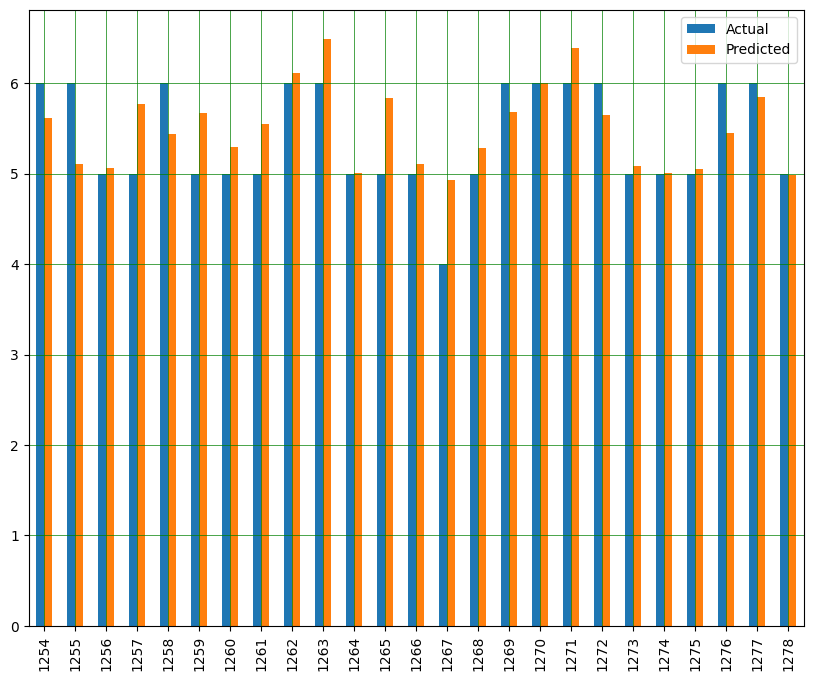

In [ ]:
df1.plot(kind='bar',figsize=(10,8))
plt.grid(which='major', linestyle='-', linewidth='0.5', color='green')
plt.grid(which='minor', linestyle=':', linewidth='0.5', color='black')
plt.show()

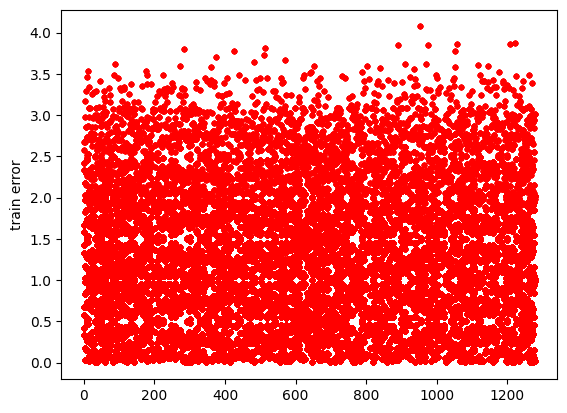

In [ ]:
plt.plot(train_error,'r.')
plt.ylabel('train error')
plt.show()

In [ ]:
# testing the model with the test data
prediction = estimator.predict(X_test)

test_error =  np.abs(Y_test - prediction)
mean_error = np.mean(test_error)
min_error = np.min(test_error)
max_error = np.max(test_error)
std_error = np.std(test_error)
print('\nTesting results:\nmean=',mean_error,'\nmin=',min_error,'\nmax=',max_error,'\nstd=',std_error)

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 

Testing results:
mean= 0.700293526891619 
min= 0.0008649826049804688 
max= 3.8015594482421875 
std= 0.531783670476588


In [ ]:
# and showing the results
df = pd.DataFrame({'Actual': Y_test, 'Predicted': prediction.ravel() })
df1 = df.tail(25)
print(df1)

     Actual  Predicted
295     6.0   5.854415
296     6.0   5.420167
297     5.0   5.651463
298     6.0   5.181044
299     5.0   5.187390
300     6.0   5.616779
301     5.0   4.915321
302     6.0   5.619940
303     6.0   5.818970
304     6.0   5.683481
305     6.0   6.046209
306     5.0   5.049214
307     5.0   5.012087
308     6.0   5.993573
309     5.0   5.578454
310     5.0   5.792265
311     6.0   6.296046
312     5.0   5.585809
313     5.0   5.105815
314     5.0   5.440289
315     6.0   5.644395
316     4.0   5.820071
317     5.0   5.721967
318     4.0   4.931928
319     6.0   5.598340


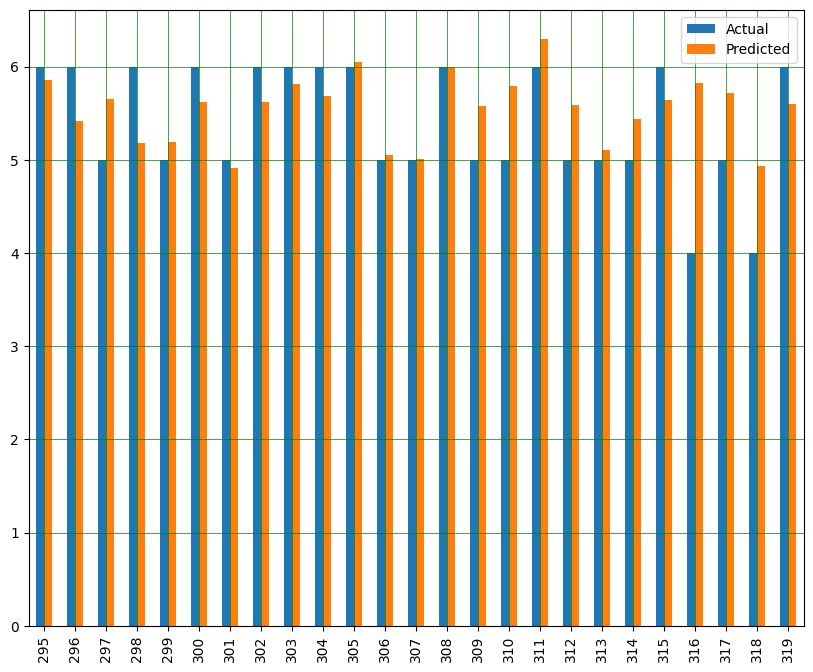

In [ ]:
df1.plot(kind='bar',figsize=(10,8))
plt.grid(which='major', linestyle='-', linewidth='0.5', color='green')
plt.grid(which='minor', linestyle=':', linewidth='0.5', color='black')
plt.show()

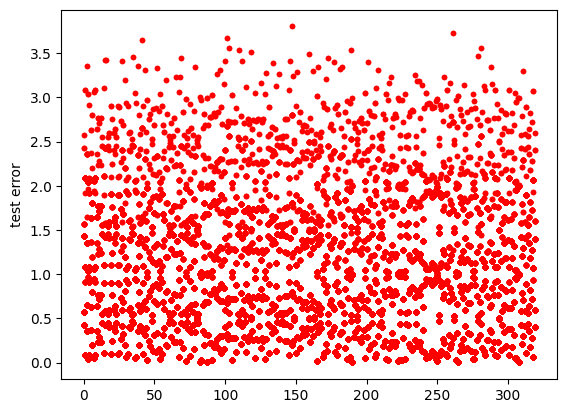

In [ ]:
plt.plot(test_error,'r.')
plt.ylabel('test error')
plt.show()

##  Practices
1. train the model for 1400 epochs. what are the training and testing MAE?
2. repeat that with 6000 training epochs. what are the training and testing MAE?
3. move back to 900 training epochs. add two convolutional and one dense layer with the same features of the layers used. what are the training and testing MAE?
4. go for 6000 training epochs. Do you feel any overfitting?
5. set back everything to the original setting, then try to normalize the training and testing features and outputs using standard_scaler. Then see if anything gets better or not. You may use insttructions like what you can see in the next cell.  

#### points:
- use GPU as your runtime type
- if the notebook overflows, change the verbose to 0, e.g. verbose=0 in the training cell.

In [ ]:
'''
# normalization
from sklearn.preprocessing import StandardScaler

# Create scalers
scaler_X = StandardScaler()
scaler_y = StandardScaler()

# Standardize X_train and X_test
X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

# Standardize Y_train and Y_test (only if y is continuous, e.g., in regression)
y_train_scaled = scaler_y.fit_transform(Y_train.reshape(-1, 1))  # Reshape if needed
y_test_scaled = scaler_y.transform(Y_test.reshape(-1, 1))
'''

'\n# normalization\nfrom sklearn.preprocessing import StandardScaler\n\n# Create scalers\nscaler_X = StandardScaler()\nscaler_y = StandardScaler()\n\n# Standardize X_train and X_test\nX_train_scaled = scaler_X.fit_transform(X_train)\nX_test_scaled = scaler_X.transform(X_test)\n\n# Standardize Y_train and Y_test (only if y is continuous, e.g., in regression)\ny_train_scaled = scaler_y.fit_transform(Y_train.reshape(-1, 1))  # Reshape if needed\ny_test_scaled = scaler_y.transform(Y_test.reshape(-1, 1))\n'